In [1]:
import sys

print(sys.executable)

/home/sanket/satellite-geospatial-dl/.venv/bin/python


In [2]:
import json

geojson_path = "../data/raw/33cae6.geojson"

with open(geojson_path, "r") as f:
    geojson = json.load(f)

print("Type:", geojson["type"])
print("Number of features:", len(geojson["features"]))
print("CRS:", geojson.get("crs"))

Type: FeatureCollection
Number of features: 4439
CRS: {'type': 'name', 'properties': {'name': 'urn:ogc:def:crs:OGC:1.3:CRS84'}}


In [6]:
import rasterio

src_path = "../data/raw/33cae6.tif"

data = rasterio.open(src_path)

print("Type:", type(data))
print("Width:", data.width)
print("Height:", data.height)
print("Bands:", data.count)
print("CRS:", data.crs)
print("Resolution:", data.res)
print("Bounds:", data.bounds)

Type: <class 'rasterio.io.DatasetReader'>
Width: 37113
Height: 34306
Bands: 4
CRS: EPSG:32737
Resolution: (0.0774800032377243, 0.0774800032377243)
Bounds: BoundingBox(left=531847.0, bottom=9365189.971008927, right=534722.5153601617, top=9367848.0)


In [7]:
import os

dst_res = 0.1
dst_path = "../data/processed/33cae6_0.1m.tif"

command = (
    f"gdalwarp -co COMPRESS=JPEG -co TILED=YES "
    f"-co NUM_THREADS=ALL_CPUS -r bilinear "
    f"-tr {dst_res} -{dst_res} "
    f"{src_path} {dst_path}"
)

print(command)
os.system(command)

gdalwarp -co COMPRESS=JPEG -co TILED=YES -co NUM_THREADS=ALL_CPUS -r bilinear -tr 0.1 -0.1 ../data/raw/33cae6.tif ../data/processed/33cae6_0.1m.tif
Using band 4 of source image as alpha.
Creating output file that is 28755P x 26580L.
Processing ../data/raw/33cae6.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.


0

In [8]:
img = rasterio.open(dst_path)

print("Width:", img.width)
print("Height:", img.height)
print("Bands:", img.count)
print("CRS:", img.crs)
print("Resolution:", img.res)

Width: 28755
Height: 26580
Bands: 4
CRS: EPSG:32737
Resolution: (0.1, 0.1)


In [11]:
import matplotlib.pyplot as plt

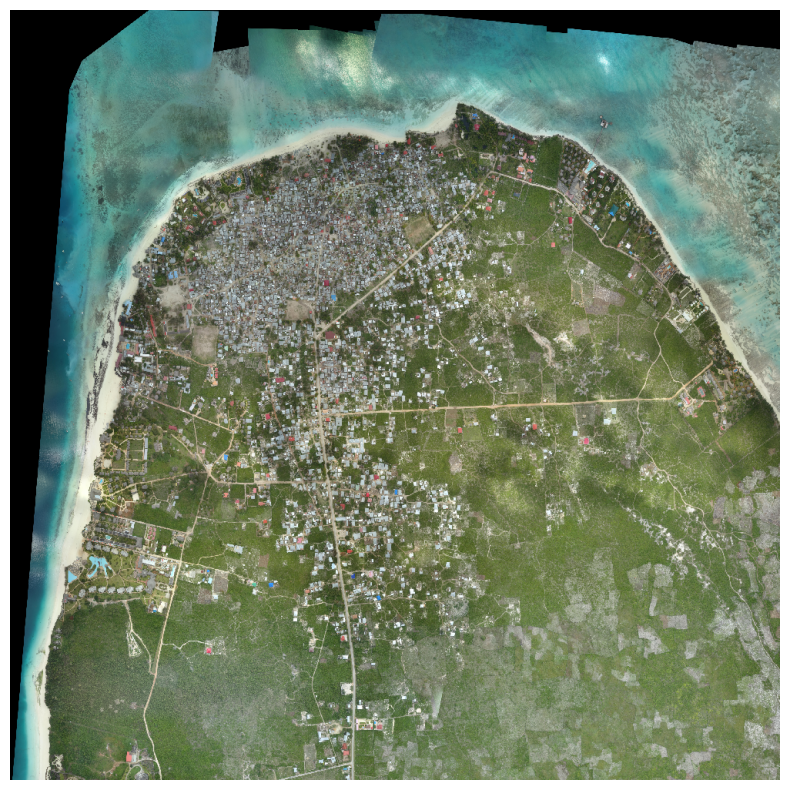

In [ ]:
import rasterio

img = rasterio.open("../data/processed/33cae6_0.1m.tif")

preview = img.read(
    [1, 2, 3],
    out_shape=(3, 1000, 1000)
)

plt.figure(figsize=(10, 10))
plt.imshow(preview.transpose(1, 2, 0))
plt.axis("off");

In [2]:
import geopandas as gpd

geo_path = "../data/raw/33cae6.geojson"

gdf = gpd.read_file(geo_path)

print("Number of buildings:", len(gdf))
print("CRS:", gdf.crs)

Number of buildings: 4439
CRS: EPSG:4326


In [3]:
gdf = gdf.to_crs(img.crs)

print("Reprojected CRS:", gdf.crs)

Reprojected CRS: PROJCS["WGS 84 / UTM zone 37S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",39],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32737"]]


In [4]:
from rasterio.features import rasterize

shapes = [(geom, 1) for geom in gdf.geometry if geom is not None]

mask = rasterize(
    shapes,
    out_shape=(img.height, img.width),
    transform=img.transform,
    fill=0,
    dtype="uint8"
)

print("Mask shape:", mask.shape)
print("Mask dtype:", mask.dtype)

Mask shape: (26580, 28755)
Mask dtype: uint8


In [5]:
mask_path = "../data/processed/33cae6_mask.tif"

mask_profile = img.profile.copy()

mask_profile.update(
    driver="GTiff",
    count=1,
    dtype="uint8",
    compress="LZW"
)

with rasterio.open(mask_path, "w", **mask_profile) as dst:
    dst.write(mask, 1)

print("Saved mask to:", mask_path)

Saved mask to: ../data/processed/33cae6_mask.tif


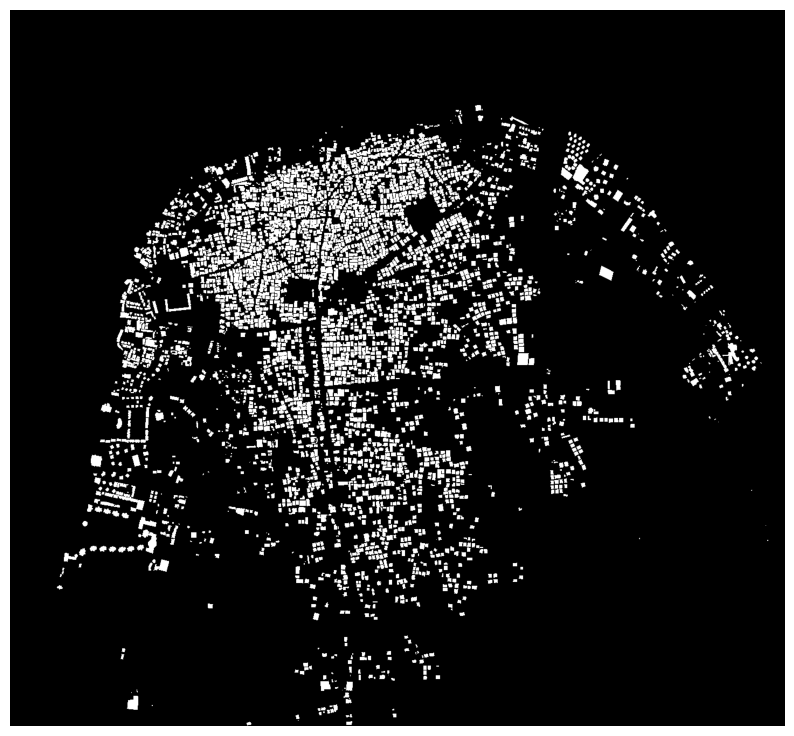

In [6]:
plt.figure(figsize=(10, 10))

mask_preview = mask[::20, ::20]

plt.imshow(mask_preview, cmap="gray")
plt.axis("off");

In [7]:
import os

dst_image_dir = "../data/images"
dst_mask_dir = "../data/masks"

os.makedirs(dst_image_dir, exist_ok=True)
os.makedirs(dst_mask_dir, exist_ok=True)

size = 1024

print("Tile size:", size)
print("Image tiles directory:", dst_image_dir)
print("Mask tiles directory:", dst_mask_dir)

Tile size: 1024
Image tiles directory: ../data/images
Mask tiles directory: ../data/masks


In [9]:
from rasterio.windows import Window
import os

def generate_image_tiles(src, output_dir, tile_size=1024):
    os.makedirs(output_dir, exist_ok=True)

    tile_count = 0

    for y in range(0, src.height, tile_size):
        for x in range(0, src.width, tile_size):

            width = min(tile_size, src.width - x)
            height = min(tile_size, src.height - y)

            window = Window(x, y, width, height)

            tile = src.read(window=window)
            transform = src.window_transform(window)

            profile = src.profile.copy()
            profile.update(
                width=width,
                height=height,
                transform=transform
            )

            tile_path = os.path.join(
                output_dir,
                f"33cae6_{tile_count:05d}.tif"
            )

            with rasterio.open(tile_path, "w", **profile) as dst:
                dst.write(tile)

            tile_count += 1

    print("Image tiles created:", tile_count)

In [10]:
generate_image_tiles(img, dst_image_dir, size)

Image tiles created: 754


In [11]:
def generate_mask_tiles(mask_src, output_dir, tile_size=1024):
    os.makedirs(output_dir, exist_ok=True)

    tile_count = 0

    for y in range(0, mask_src.height, tile_size):
        for x in range(0, mask_src.width, tile_size):

            width = min(tile_size, mask_src.width - x)
            height = min(tile_size, mask_src.height - y)

            window = Window(x, y, width, height)

            tile = mask_src.read(window=window)
            transform = mask_src.window_transform(window)

            profile = mask_src.profile.copy()
            profile.update(
                width=width,
                height=height,
                transform=transform
            )

            tile_path = os.path.join(
                output_dir,
                f"33cae6_{tile_count:05d}.tif"
            )

            with rasterio.open(tile_path, "w", **profile) as dst:
                dst.write(tile)

            tile_count += 1

    print("Mask tiles created:", tile_count)

In [12]:
mask_src = rasterio.open(mask_path)

generate_mask_tiles(mask_src, dst_mask_dir, size)

Mask tiles created: 754


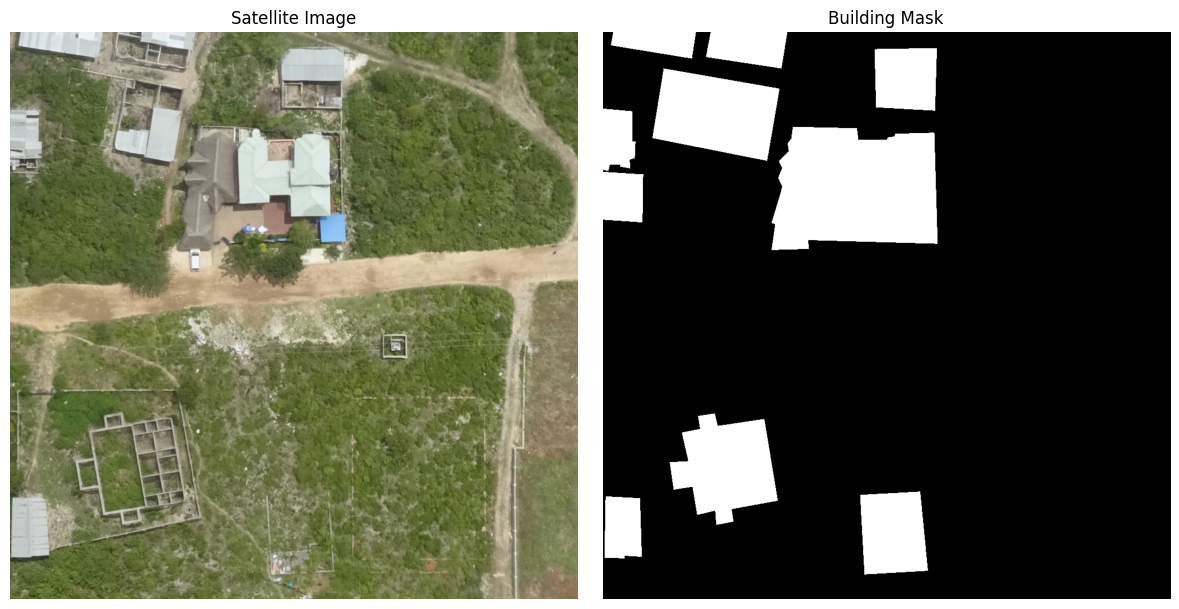

In [13]:
import random
import os
import matplotlib.pyplot as plt

image_files = sorted([
    f for f in os.listdir(dst_image_dir)
    if f.endswith(".tif")
])

tile_name = random.choice(image_files)

image_tile_path = os.path.join(dst_image_dir, tile_name)
mask_tile_path = os.path.join(dst_mask_dir, tile_name)

with rasterio.open(image_tile_path) as src_img:
    image_tile = src_img.read([1, 2, 3])

with rasterio.open(mask_tile_path) as src_mask:
    mask_tile = src_mask.read(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(image_tile.transpose(1, 2, 0))
axes[0].set_title("Satellite Image")

axes[1].imshow(mask_tile, cmap="gray")
axes[1].set_title("Building Mask")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()